# 05 · Interrupts

**What this teaches:** how to pause a running graph, hand control to a human, and
resume where it left off.

We take the triangle classifier from [03-edges.ipynb](./03-edges.ipynb) and give it a
problem it cannot solve alone: three lengths that do not form a triangle.

## What is an interrupt?

From the [interrupts docs](https://docs.langchain.com/oss/python/langgraph/interrupts):

> "Interrupts allow you to pause graph execution at specific points and wait for
> external input before continuing."

Calling `interrupt(value)` inside a node stops the graph and surfaces `value` to the
caller. Later you call the graph again with
[`Command(resume=...)`](https://docs.langchain.com/oss/python/langgraph/interrupts#resuming-interrupts):

> "The resume value is passed back into the node when you resume, becoming the return
> value of the `interrupt()` call."

Interrupts are built on checkpoints, so [04-memory.ipynb](./04-memory.ipynb) comes
first — you cannot resume what was never saved.

In [1]:
import operator
from typing import Annotated, Literal

from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from typing_extensions import TypedDict

In [2]:
def show(graph):
    """Draw the graph. Falls back to Mermaid source if mermaid.ink is unreachable."""
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        print(graph.get_graph().draw_mermaid())

## The triangle inequality

Three lengths only form a triangle if the two shortest add up to more than the
longest. `2, 3, 9` does not: 2 + 3 is less than 9, so the short sides cannot meet.

In 03 the classifier assumed its input was valid. Now it checks, and asks when it
isn't. Look at where `interrupt()` sits — its return value *is* the replacement side.

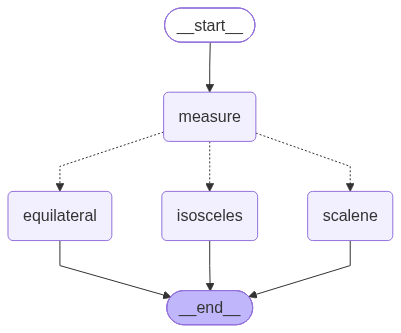

In [3]:
class Triangle(TypedDict):
    sides: list[float]
    notes: Annotated[list[str], operator.add]


def measure_and_classify(
    state: Triangle,
) -> Command[Literal["equilateral", "isosceles", "scalene"]]:
    a, b, c = sorted(state["sides"])
    print(f"---measure_and_classify--- {a}, {b}, {c}")

    if a + b <= c:
        # pause here; whatever the human sends back becomes the new longest side
        c = interrupt(f"{a}, {b}, {c} is not a triangle: {a} + {b} <= {c}. Give a shorter longest side.")

    sides = sorted([a, b, c])
    distinct = len(set(sides))
    kind = "equilateral" if distinct == 1 else "isosceles" if distinct == 2 else "scalene"

    return Command(update={"sides": sides, "notes": [f"sides {sides}"]}, goto=kind)


def equilateral(state: Triangle) -> dict:
    return {"notes": ["equilateral: all three sides equal"]}


def isosceles(state: Triangle) -> dict:
    return {"notes": ["isosceles: exactly two sides equal"]}


def scalene(state: Triangle) -> dict:
    return {"notes": ["scalene: no two sides equal"]}


builder = StateGraph(Triangle)
builder.add_node("measure", measure_and_classify)
builder.add_node("equilateral", equilateral)
builder.add_node("isosceles", isosceles)
builder.add_node("scalene", scalene)

builder.add_edge(START, "measure")
builder.add_edge("equilateral", END)
builder.add_edge("isosceles", END)
builder.add_edge("scalene", END)

graph = builder.compile(checkpointer=InMemorySaver())
show(graph)

## Valid sides: nothing changes

`3, 3, 3` is a triangle, so `interrupt()` is never reached and the graph runs straight
through.

In [4]:
happy = {"configurable": {"thread_id": "happy"}}
graph.invoke({"sides": [3, 3, 3], "notes": []}, happy)

---measure_and_classify--- 3, 3, 3


{'sides': [3, 3, 3],
 'notes': ['sides [3, 3, 3]', 'equilateral: all three sides equal']}

## Invalid sides: the graph pauses

The call still returns — it does not block or raise — but the result is different.

In [5]:
thread = {"configurable": {"thread_id": "1"}}
result = graph.invoke({"sides": [2, 3, 9], "notes": []}, thread)

print("keys in result:", list(result.keys()))
print("notes so far:  ", result["notes"])

---measure_and_classify--- 2, 3, 9
keys in result: ['sides', 'notes', '__interrupt__']
notes so far:   []


### Detecting the pause

A paused run puts an `__interrupt__` key in the result holding the values passed to
`interrupt()`.

In [6]:
if "__interrupt__" in result:
    print("the graph is asking:", result["__interrupt__"][-1].value)

the graph is asking: 2, 3, 9 is not a triangle: 2 + 3 <= 9. Give a shorter longest side.


`notes` is still empty. The node had not returned yet, so its `Command(update=...)`
was never applied — **an interrupted node contributes nothing until it completes.**

The checkpoint confirms the graph is parked *before* `measure`, not after it:

In [7]:
print("next node to run:", graph.get_state(thread).next)

next node to run: ('measure',)


## Resuming

Call the graph again on the **same thread** with `Command(resume=<answer>)`. No
initial state — the thread already has it.

In [8]:
resumed = graph.invoke(Command(resume=4), thread)
print(resumed)

---measure_and_classify--- 2, 3, 9
{'sides': [2, 3, 4], 'notes': ['sides [2, 3, 4]', 'scalene: no two sides equal']}


`4` became the return value of `interrupt()`, so the sides became `2, 3, 4` and the
node routed to `scalene`.

Look at the printed trace: `measure_and_classify` ran **twice**, both times starting
from `2, 3, 9`. That is the most important rule about interrupts.

## Rules of interrupts

These are the [documented gotchas](https://docs.langchain.com/oss/python/langgraph/interrupts#rules-of-interrupts).

**1. The node restarts from the top.**

> "The runtime restarts the entire node from the beginning — it does not resume from
> the exact line where `interrupt` was called."

On resume the node ran again from its first statement. `interrupt()` returned the
resume value instead of pausing this time, so execution continued past it.

**2. Side effects before `interrupt()` happen twice.** Because of rule 1, anything the
node did before pausing runs again. The docs say side effects "should (ideally) be
idempotent". Put them *after* the interrupt, or in a node of their own.

**3. Never wrap `interrupt()` in `try`/`except`.**

> "If you wrap the interrupt call in a try/except block, you will catch this exception
> and the interrupt will not be passed back."

**4. Matching is index-based.** With several `interrupt()` calls in one node, resume
values are matched by call order, so do not skip or loop over them conditionally. The
docs warn against `while` loops that interrupt repeatedly: "the result is exponential
re-execution."

Rule 4 is why this notebook accepts the replacement side without re-checking it. A
loop that kept asking until the sides were valid is exactly the shape the docs warn
about; validating in a separate node before routing is the safer design.

### Rule 1, demonstrated

A print before the interrupt fires on the first pass and again on resume.

In [9]:
def noisy_node(state: Triangle) -> dict:
    print("  ...top of noisy_node (runs on every pass)")
    answer = interrupt("give me a side length")
    print(f"  ...past the interrupt, got {answer!r}")
    return {"notes": [f"side {answer}"]}


noisy = StateGraph(Triangle)
noisy.add_node("noisy_node", noisy_node)
noisy.add_edge(START, "noisy_node")
noisy.add_edge("noisy_node", END)
noisy_graph = noisy.compile(checkpointer=InMemorySaver())

noisy_thread = {"configurable": {"thread_id": "noisy"}}

print("first invoke:")
noisy_graph.invoke({"sides": [], "notes": []}, noisy_thread)

print("resume:")
print(noisy_graph.invoke(Command(resume=7), noisy_thread))

first invoke:
  ...top of noisy_node (runs on every pass)
resume:
  ...top of noisy_node (runs on every pass)
  ...past the interrupt, got 7
{'sides': [], 'notes': ['side 7']}


## A checkpointer is required to resume

`interrupt()` will pause without one, which is misleading — the failure arrives later,
at resume time, because there is no saved checkpoint to resume *from*.

In [10]:
no_memory = builder.compile()          # no checkpointer

paused = no_memory.invoke({"sides": [2, 3, 9], "notes": []})
print("it still pauses:", "__interrupt__" in paused)

try:
    no_memory.invoke(Command(resume=4))
except RuntimeError as e:
    print("but resuming fails:", e)

---measure_and_classify--- 2, 3, 9
it still pauses: True
but resuming fails: Cannot use Command(resume=...) without checkpointer


## In a real application

The cells above hard-code `4` as the answer so the notebook runs unattended. Real code
does the same three steps with a human in the middle:

```python
result = graph.invoke({"sides": sides, "notes": []}, thread)

while "__interrupt__" in result:
    question = result["__interrupt__"][-1].value
    answer = ask_the_human(question)          # a web request, a form, a Slack reply
    result = graph.invoke(Command(resume=answer), thread)
```

Because the state lives in the checkpointer and not in local variables, the pause can
last milliseconds or days, and the process may restart in between — as long as the
checkpointer is durable (SQLite or Postgres, from 04) and you keep the `thread_id`.

## Static interrupts

There is an older, coarser mechanism: pause before or after a named node without
touching the node's code.

```python
graph = builder.compile(
    checkpointer=InMemorySaver(),
    interrupt_before=["scalene"],     # or interrupt_after=[...]
)
```

Resume by invoking with `None` instead of `Command(resume=...)`. These
[static interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts) are
useful for debugging — pause anywhere, inspect, continue — but they cannot ask a
question or receive an answer.